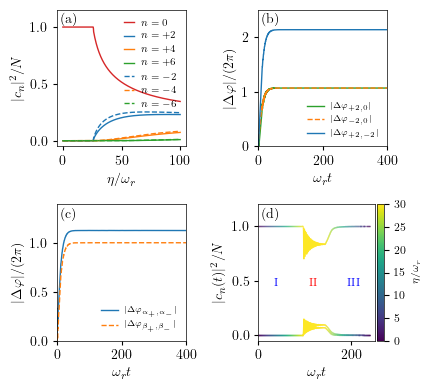

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# ============================================================
# LOAD DATA
# ============================================================
data = np.load(r"Figure6_data.npz")

eta_vals = data["eta_vals"]
omega_r = data["omega_r"]

pop_0 = data["pop_0"]
pop_p2 = data["pop_p2"]
pop_p4 = data["pop_p4"]
pop_p6 = data["pop_p6"]
pop_m2 = data["pop_m2"]
pop_m4 = data["pop_m4"]
pop_m6 = data["pop_m6"]

t_phase = data["t_phase"]
delta_p0 = data["delta_p0"]
delta_m0 = data["delta_m0"]
delta_pm = data["delta_pm"]
delta_apm = data["delta_apm"]
delta_bpm = data["delta_bpm"]

t_ramp = data["t_ramp"]
eta_ramp = data["eta_ramp"]
pop0_r = data["pop0_r"]
popP_r = data["popP_r"]
popM_r = data["popM_r"]

# ============================================================
# REQUIRED FUNCTION
# ============================================================
def colored_time_line(ax, x, y, c, cmap="viridis", lw=1.0):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap)
    lc.set_array(c)
    lc.set_linewidth(lw)

    ax.add_collection(lc)
    ax.set_xlim(x.min(), x.max())

    return lc

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# APS COMPACT STYLE (for 3.8 x 4.0 figure)
# ============================================================

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 7,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.5,
    "lines.linewidth": 1.0,
})

# ============================================================
# FIGURE
# ============================================================

fig, axs = plt.subplots(2, 2, figsize=(4.4, 4))
plt.subplots_adjust(wspace=0.55, hspace=0.35)

ax1, ax2 = axs[0]
ax3, ax4 = axs[1]

# ============================================================
# (a) populations
# ============================================================

ax1.plot(eta_vals/omega_r, pop_0,  color='C3', label=r'$n=0$')
ax1.plot(eta_vals/omega_r, pop_p2, color='C0', label=r'$n=+2$')
ax1.plot(eta_vals/omega_r, pop_p4, color='C1', label=r'$n=+4$')
ax1.plot(eta_vals/omega_r, pop_p6, color='C2', label=r'$n=+6$')
ax1.plot(eta_vals/omega_r, pop_m2, '--', color='C0', label=r'$n=-2$')
ax1.plot(eta_vals/omega_r, pop_m4, '--', color='C1', label=r'$n=-4$')
ax1.plot(eta_vals/omega_r, pop_m6, '--', color='C2', label=r'$n=-6$')

ax1.set_xlabel(r'$\eta/\omega_r$')
ax1.set_ylabel(r'$|c_n|^2/N$')
ax1.set_ylim(-0.05, 1.15)
ax1.legend(
    frameon=False,
    ncol=1,
    loc='upper right',
    handlelength=1,
    columnspacing=0.2
)

ax1.text(0.03, 0.9, '(a)', transform=ax1.transAxes)

# ============================================================
# (b) atomic phase
# ============================================================

ax2.plot(omega_r*t_phase, np.abs(delta_p0)/(2*np.pi),
         color='C2', label=r'$|\Delta \varphi_{+2,0}|$')

ax2.plot(omega_r*t_phase, np.abs(delta_m0)/(2*np.pi),
         '--', color='C1', label=r'$|\Delta \varphi_{-2,0}|$')

ax2.plot(omega_r*t_phase, np.abs(delta_pm)/(2*np.pi),
         color='C0', label=r'$|\Delta \varphi_{+2,-2}|$')

ax2.set_xlabel(r"$\omega_r t$")
ax2.set_ylabel(r"$|\Delta \varphi|/(2\pi)$")
ax2.set_xlim(0, 400)
ax2.set_ylim(0, 2.5)

ax2.legend(frameon=False, fontsize=6, loc='lower right')

ax2.text(0.03, 0.9, '(b)', transform=ax2.transAxes)

# ============================================================
# (c) cavity phase
# ============================================================

ax3.plot(omega_r*t_phase, np.abs(delta_apm)/(2*np.pi),
         label=r'$|\Delta \varphi_{\alpha_+,\alpha_-}|$')

ax3.plot(omega_r*t_phase, np.abs(delta_bpm)/(2*np.pi),
         '--', label=r'$|\Delta \varphi_{\beta_+,\beta_-}|$')

ax3.set_xlabel(r"$\omega_r t$")
ax3.set_ylabel(r"$|\Delta \varphi|/(2\pi)$")
ax3.set_xlim(0, 400)
ax3.set_ylim(0, 1.4)

ax3.legend(frameon=False, fontsize=6, loc='lower right')

ax3.text(0.03, 0.9, '(c)', transform=ax3.transAxes)

# ============================================================
# (d) ramp dynamics
# ============================================================

x = omega_r * t_ramp
c = eta_ramp / omega_r

lc0 = colored_time_line(ax4, x, pop0_r, c, cmap="viridis")
colored_time_line(ax4, x, popP_r, c, cmap="viridis")
colored_time_line(ax4, x, popM_r, c, cmap="viridis")

ax4.set_xlim(0, 250)
ax4.set_ylim(-0.05, 1.2)

ax4.set_xlabel(r"$\omega_r t$")
ax4.set_ylabel(r"$|c_n(t)|^2/N$")

ax4.text(0.03, 0.9, '(d)', transform=ax4.transAxes)
# Regime labels
ax4.text(1.7, 0.4, 'I', transform=ax3.transAxes,
         fontsize=8, fontweight='bold', color='blue', ha='center')
ax4.text(1.99, 0.4, 'II', transform=ax3.transAxes,
         fontsize=8, fontweight='bold', color='red', ha='center')
ax4.text(2.3, 0.4, 'III', transform=ax3.transAxes,
         fontsize=8, fontweight='bold', color='blue', ha='center')

# ============================================================
# COLORBAR (compact)
# ============================================================

cbar = fig.colorbar(lc0, ax=ax4, fraction=0.08, pad=0.02)
cbar.set_label(r'$\eta/\omega_r$', fontsize=7)
cbar.ax.tick_params(labelsize=8)

# ============================================================
# CLEAN LOOK
# ============================================================

for ax in axs.flat:
    ax.tick_params(direction='out', length=3, width=0.8)

plt.tight_layout()
plt.show()